In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
panel_df = pd.read_csv("../data/clean/panel.csv")

In [3]:
cvd_all = panel_df[panel_df['Topic']=='Cardiovascular Disease']
for year in [2019, 2020, 2021, 2022, 2023]:
    y = cvd_all[cvd_all['YearStart']==year]
    print(year, 
          'total:', len(y),
          'prev:', y['prevalence'].notna().sum(),
          'mort:', y['mortality'].notna().sum(),
          'both:', (y['prevalence'].notna() & y['mortality'].notna()).sum())

2019 total: 53 prev: 52 mort: 51 both: 50
2020 total: 51 prev: 0 mort: 51 both: 0
2021 total: 54 prev: 53 mort: 51 both: 50
2022 total: 51 prev: 0 mort: 51 both: 0
2023 total: 52 prev: 52 mort: 0 both: 0


In [4]:
for topic in panel_df['Topic'].unique():
    d = panel_df[panel_df['Topic']==topic]
    for year in [2019, 2020, 2021, 2022, 2023]:
        y = d[d['YearStart']==year]
        both = (y['prevalence'].notna() & y['mortality'].notna()).sum()
        print(topic, year, 'both:', both)
    print()

Asthma 2019 both: 37
Asthma 2020 both: 39
Asthma 2021 both: 37
Asthma 2022 both: 39
Asthma 2023 both: 0

Cardiovascular Disease 2019 both: 50
Cardiovascular Disease 2020 both: 0
Cardiovascular Disease 2021 both: 50
Cardiovascular Disease 2022 both: 0
Cardiovascular Disease 2023 both: 0

Chronic Obstructive Pulmonary Disease 2019 both: 50
Chronic Obstructive Pulmonary Disease 2020 both: 51
Chronic Obstructive Pulmonary Disease 2021 both: 50
Chronic Obstructive Pulmonary Disease 2022 both: 51
Chronic Obstructive Pulmonary Disease 2023 both: 0

Diabetes 2019 both: 50
Diabetes 2020 both: 51
Diabetes 2021 both: 50
Diabetes 2022 both: 51
Diabetes 2023 both: 0



In [5]:
panel_df['hospitalization'] = panel_df['hospitalization'] * 100
panel_df['hospitalization_lo'] = panel_df['hospitalization_lo'] * 100
panel_df['hospitalization_hi'] = panel_df['hospitalization_hi'] * 100

In [6]:
panel_df.head(10)

,LocationAbbr,YearStart,Topic,hospitalization,mortality,prevalence,hospitalization_lo,mortality_lo,prevalence_lo,hospitalization_hi,mortality_hi,prevalence_hi
0,AK,2019,Asthma,NaN,NaN,10.5,NaN,NaN,8.9,NaN,NaN,12.4
1,AK,2019,Cardiovascular Disease,980.0,129.7,32.8,905.0,120.5,30.4,1055.0,138.9,35.3
2,AK,2019,Chronic Obstructive Pulmonary Disease,366.0,81.7,4.6,320.0,69.4,3.7,412.0,93.9,5.6
3,AK,2019,Diabetes,NaN,45.8,7.2,NaN,40.4,6.1,NaN,51.2,8.5
4,AK,2020,Asthma,NaN,NaN,9.8,NaN,NaN,8.4,NaN,NaN,11.5
5,AK,2020,Cardiovascular Disease,869.0,139.8,NaN,800.0,130.4,NaN,938.0,149.3,NaN
6,AK,2020,Chronic Obstructive Pulmonary Disease,164.0,81.8,4.6,135.0,69.5,3.8,194.0,94.1,5.5
7,AK,2020,Diabetes,NaN,65.8,7.4,NaN,59.5,6.4,NaN,72.2,8.6
8,AK,2021,Asthma,NaN,NaN,9.9,NaN,NaN,8.8,NaN,NaN,11.2
9,AK,2021,Cardiovascular Disease,953.0,154.7,29.9,881.0,144.6,28.3,1024.0,164.8,31.6


Text(0, 0.5, 'Mortality')

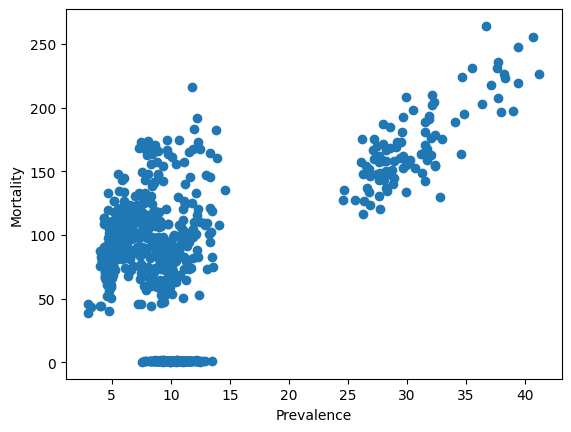

In [7]:
plt.scatter(panel_df['prevalence'],panel_df['mortality'])
plt.xlabel('Prevalence')
plt.ylabel('Mortality')

In [8]:
# Let's focus only on Cardiovascular disease and Chronic Obstructive Pulmonary Disease but analyze for all 4 because
# CMS data is not available for Diabetes and Asthma

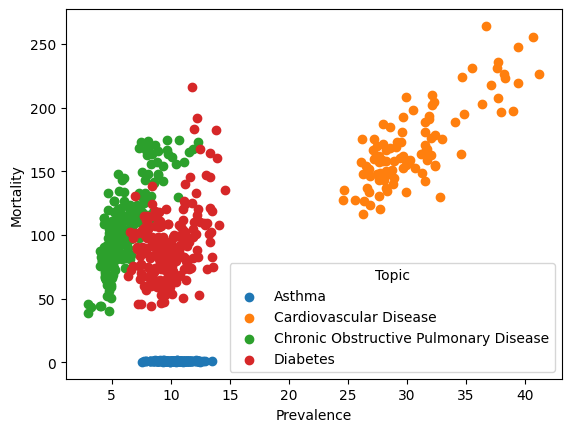

In [9]:
for name, group in panel_df.groupby('Topic'):
    plt.scatter(group['prevalence'], group['mortality'], label=name)

plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.legend(title='Topic')

Text(0.5, 1.0, 'Prevalence vs Mortality for Asthma')

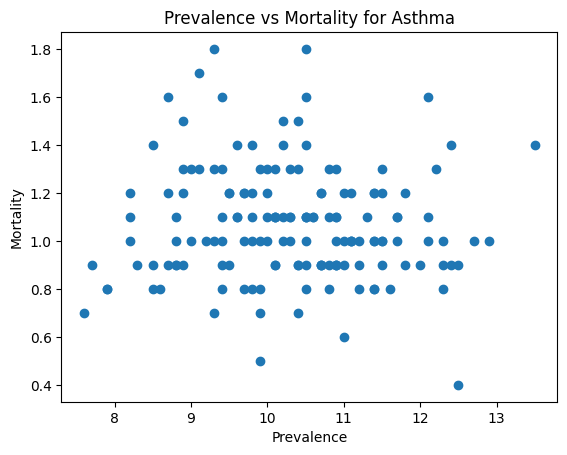

In [10]:
asthma = panel_df.loc[panel_df['Topic'] == 'Asthma']
plt.scatter(asthma['prevalence'], asthma['mortality'])
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Asthma')

Text(0.5, 1.0, 'Prevalence vs Mortality for Cardiovascular Disease')

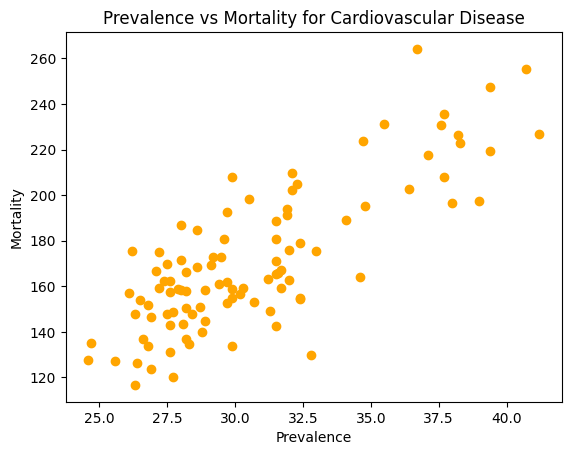

In [11]:
cvd = panel_df.loc[panel_df['Topic'] == 'Cardiovascular Disease']
plt.scatter(cvd['prevalence'], cvd['mortality'], color='orange')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Cardiovascular Disease')

Text(0.5, 1.0, 'Prevalence vs Mortality for Chronic Obstructive Pulmonary Disease')

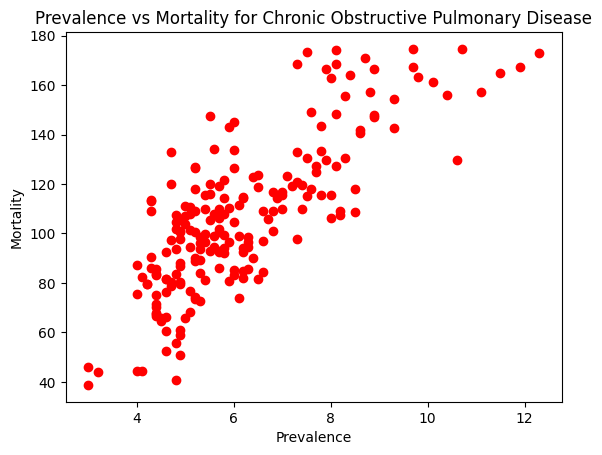

In [12]:
copd = panel_df.loc[panel_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
plt.scatter(copd['prevalence'], copd['mortality'], color='red')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Chronic Obstructive Pulmonary Disease')

Text(0.5, 1.0, 'Prevalence vs Mortality for Diabetes')

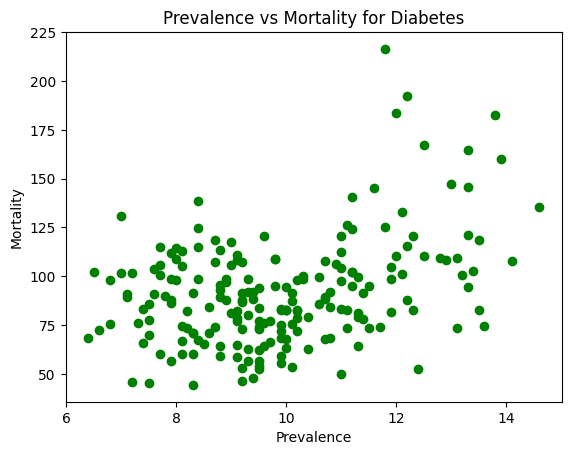

In [13]:
diabetes = panel_df.loc[panel_df['Topic'] == 'Diabetes']
plt.scatter(diabetes['prevalence'], diabetes['mortality'], color='green')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Diabetes')

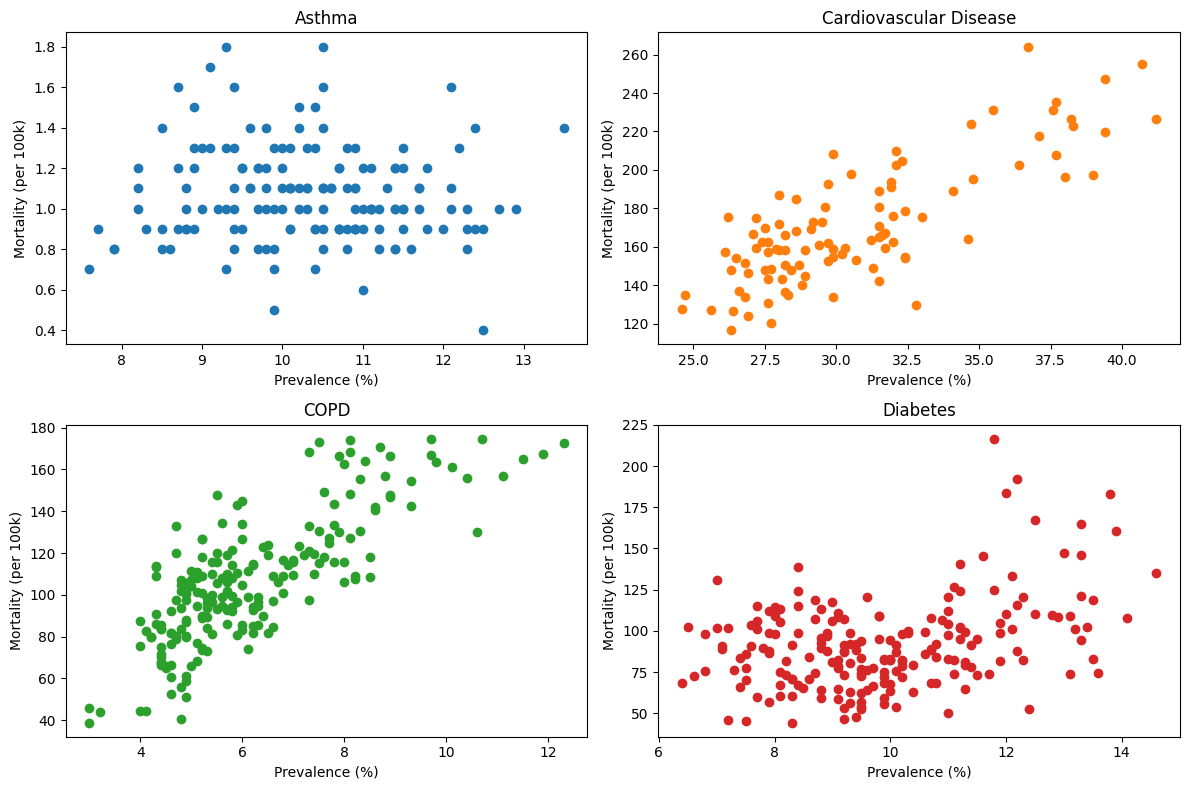

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

d = panel_df[panel_df['Topic'] == 'Asthma']
axes[0,0].scatter(d['prevalence'], d['mortality'], color='tab:blue')
axes[0,0].set_title('Asthma')

d = panel_df[panel_df['Topic'] == 'Cardiovascular Disease']
axes[0,1].scatter(d['prevalence'], d['mortality'], color='tab:orange')
axes[0,1].set_title('Cardiovascular Disease')

d = panel_df[panel_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
axes[1,0].scatter(d['prevalence'], d['mortality'], color='tab:green')
axes[1,0].set_title('COPD')

d = panel_df[panel_df['Topic'] == 'Diabetes']
axes[1,1].scatter(d['prevalence'], d['mortality'], color='tab:red')
axes[1,1].set_title('Diabetes')

for ax in axes.flat:
    ax.set_xlabel('Prevalence (%)')
    ax.set_ylabel('Mortality (per 100k)')
plt.tight_layout()
plt.show()

In [46]:
# Verify OK outlier
ok_cvd = panel_df.loc[(panel_df['LocationAbbr']=='OK') & (panel_df['Topic']=='Cardiovascular Disease') & (panel_df['YearStart']==2021)]
print(ok_cvd[['LocationAbbr', 'mortality', 'mortality_lo', 'mortality_hi']])

    LocationAbbr  mortality  mortality_lo  mortality_hi
742           OK      264.2         259.4         268.9


In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
output_groups = []

panel_2022 = panel_df[panel_df['YearStart'] == 2021]

for disease, group in panel_2022.groupby('Topic'):
    
    clean_group = group.dropna(subset=["prevalence", "mortality"]).copy()
    print(disease, len(clean_group))
    
    if len(clean_group) == 0:
        continue
    X = clean_group[['prevalence']]
    y = clean_group['mortality']
    model = LinearRegression()
    model.fit(X,y)

    clean_group['prediction'] = model.predict(X)
    residual = y - clean_group['prediction']
    clean_group['residual'] = residual

    if clean_group['residual'].std() > 0:
        clean_group['residual_z_score'] = (clean_group['residual'] - clean_group['residual'].mean()) / clean_group['residual'].std()
    else:
        clean_group['residual_z_score'] = 0.0
    output_groups.append(clean_group)

results_df = pd.concat(output_groups)
        
    



Asthma 37
Cardiovascular Disease 50
Chronic Obstructive Pulmonary Disease 50
Diabetes 50


In [44]:
# COPD best/worst
copd_res = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
copd_agg = copd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score']].sort_values('residual_z_score')
copd_best = copd_agg.head(5)
copd_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score
150,DC,2021,4.8,40.6,84.937442,-44.337442,-2.452586
643,NJ,2021,4.8,55.9,84.937442,-29.037442,-1.606246
383,LA,2021,8.2,108.9,135.826494,-26.926494,-1.489476
703,NY,2021,4.9,60.9,86.434179,-25.534179,-1.412458
1027,WV,2021,11.5,165.0,185.218810,-20.218810,-1.118431


In [43]:
copd_worst = copd_agg.tail(5).iloc[::-1]
copd_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
743,OK,2021,7.3,168.5,122.355863,46.144137,2.552526,453.0
1047,WY,2021,5.6,134.3,96.911337,37.388663,2.068205,219.0
50,AR,2021,8.7,170.9,143.310178,27.589822,1.526169,509.0
287,ID,2021,5.2,118.0,90.924390,27.075610,1.497725,235.0
523,MS,2021,8.4,163.9,138.819968,25.080032,1.387336,501.0


In [17]:
results_df

,LocationAbbr,YearStart,Topic,hospitalization,mortality,prevalence,hospitalization_lo,mortality_lo,prevalence_lo,hospitalization_hi,mortality_hi,prevalence_hi,prediction,residual,residual_z_score
28,AL,2021,Asthma,NaN,1.2,10.7,NaN,0.9,9.4,NaN,1.5,12.1,1.011076,0.188924,0.960515
48,AR,2021,Asthma,NaN,1.1,10.1,NaN,0.8,8.8,NaN,1.5,11.6,1.035670,0.064330,0.327064
68,AZ,2021,Asthma,NaN,1.0,10.0,NaN,0.8,9.3,NaN,1.3,10.9,1.039769,-0.039769,-0.202189
88,CA,2021,Asthma,NaN,0.8,9.4,NaN,0.7,8.5,NaN,0.9,10.4,1.064362,-0.264362,-1.344053
108,CO,2021,Asthma,NaN,0.8,11.2,NaN,0.6,10.5,NaN,1.0,12.0,0.990582,-0.190582,-0.968945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,VT,2021,Diabetes,NaN,101.5,7.2,NaN,94.8,6.4,NaN,108.2,8.0,82.284812,19.215188,0.724350
988,WA,2021,Diabetes,NaN,98.7,7.9,NaN,96.6,7.4,NaN,100.8,8.5,87.896395,10.803605,0.407261
1008,WI,2021,Diabetes,NaN,109.1,8.0,NaN,106.7,7.1,NaN,111.5,9.0,88.698050,20.401950,0.769087
1028,WV,2021,Diabetes,NaN,145.9,13.3,NaN,141.1,12.4,NaN,150.8,14.2,131.185750,14.714250,0.554679


In [18]:
# Let's focus on each disease at a time

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

diabetes_res = results_df.loc[results_df['Topic'] == 'Diabetes']


diabetes_agg = diabetes_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
diabetes_best = diabetes_agg.head(5)
diabetes_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
131,CT,2021,9.4,47.8,99.921216,-52.121216,-1.964800,NaN
31,AL,2021,13.5,82.9,132.789059,-49.889059,-1.880655,NaN
644,NJ,2021,8.8,59.0,95.111287,-36.111287,-1.361278,NaN
704,NY,2021,10.2,71.9,106.334453,-34.434453,-1.298067,NaN
404,MA,2021,7.9,56.8,87.896395,-31.096395,-1.172233,NaN


In [19]:
diabetes_worst = diabetes_agg.tail(5).iloc[::-1]
diabetes_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
744,OK,2021,11.8,216.4,119.160929,97.239071,3.665596,NaN
524,MS,2021,13.8,182.8,135.194023,47.605977,1.794590,NaN
368,KY,2021,12.5,167.3,124.772512,42.527488,1.603148,NaN
151,DC,2021,8.4,124.5,91.904669,32.595331,1.228738,NaN
1048,WY,2021,7.7,115.0,86.293086,28.706914,1.082157,NaN


In [20]:
# Asthma

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

Asthma_res = results_df.loc[results_df['Topic'] == 'Asthma']


Asthma_agg = Asthma_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
Asthma_best = Asthma_agg.head(5)
Asthma_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
365,KY,2021,12.5,0.4,0.937296,-0.537296,-2.731690,NaN
88,CA,2021,9.4,0.8,1.064362,-0.264362,-1.344053,NaN
681,NV,2021,9.8,0.8,1.047966,-0.247966,-1.260696,NaN
915,UT,2021,10.8,0.8,1.006977,-0.206977,-1.052303,NaN
108,CO,2021,11.2,0.8,0.990582,-0.190582,-0.968945,NaN


In [21]:
Asthma_worst = Asthma_agg.tail(5).iloc[::-1]
Asthma_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
521,MS,2021,10.4,1.5,1.023373,0.476627,2.423239,NaN
761,OR,2021,12.2,1.3,0.949593,0.350407,1.781519,NaN
345,KS,2021,11.5,1.3,0.978285,0.321715,1.635643,NaN
245,HI,2021,8.5,1.4,1.101252,0.298748,1.518878,NaN
28,AL,2021,10.7,1.2,1.011076,0.188924,0.960515,NaN


In [22]:
# Cardiovascular Disease (CVD)

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

cvd_res = results_df.loc[results_df['Topic'] == 'Cardiovascular Disease']


cvd_agg = cvd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
cvd_best = cvd_agg.head(5)
cvd_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
482,MN,2021,26.9,123.9,150.210315,-26.310315,-1.584944,2760.0
856,SD,2021,30.7,153.0,178.415027,-25.415027,-1.531012,1508.0
169,DE,2021,32.0,162.7,188.064007,-25.364007,-1.527938,1866.0
129,CT,2021,28.2,136.7,159.859295,-23.159295,-1.395126,3277.0
246,HI,2021,26.4,126.5,146.499169,-19.999169,-1.204758,1792.0


                 hospitalization  residual
hospitalization         1.000000 -0.441576
residual               -0.441576  1.000000


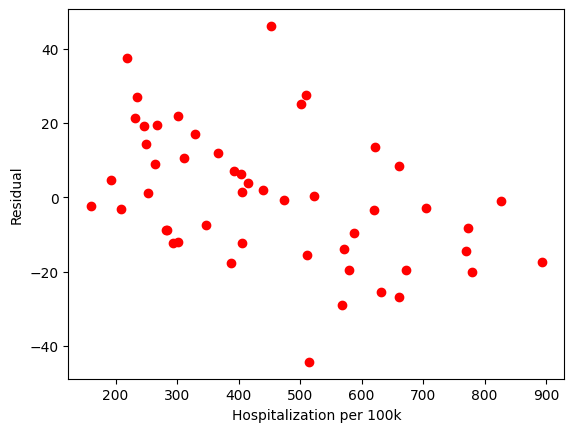

In [41]:
# Hospitalization vs Residual COPD

copd_hos = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
plt.scatter(copd_hos['hospitalization'], copd_hos['residual'], color='red')
plt.xlabel('Hospitalization per 100k')
plt.ylabel('Residual')

print(copd_hos[['hospitalization', 'residual']].corr())

,hospitalization,residual
hospitalization,1.000000,0.035113
residual,0.035113,1.000000


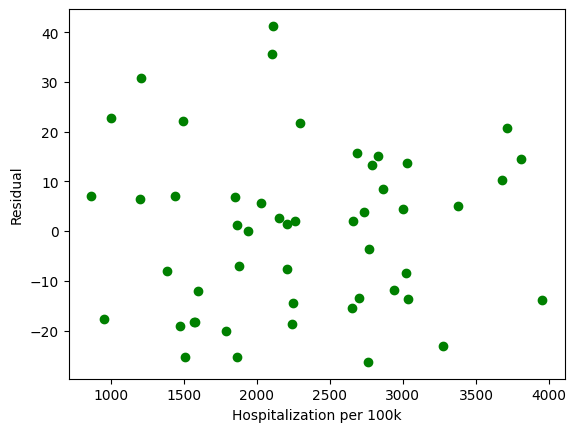

In [40]:
# Hospitalization vs Residual CVD

covd_hos = results_df.loc[results_df['Topic'] == 'Cardiovascular Disease']
plt.scatter(covd_hos['hospitalization'], covd_hos['residual'], color='green')
plt.xlabel('Hospitalization per 100k')
plt.ylabel('Residual')

covd_hos[['hospitalization', 'residual']].corr()

Text(0.5, 1.0, 'COPD residuals vs predictions')

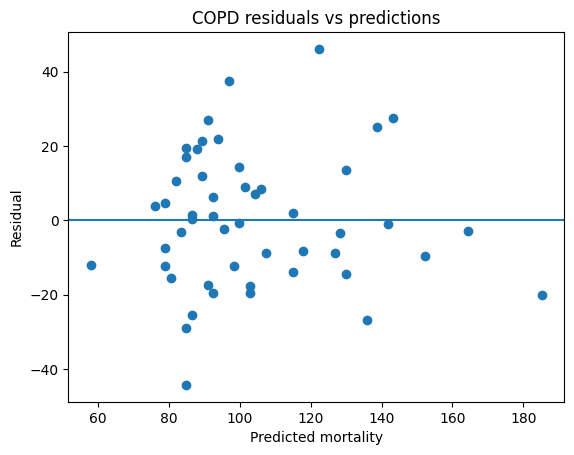

In [45]:
# COPD linearity check
plt.scatter(copd_res['prediction'], copd_res['residual'])
plt.axhline(0)
plt.xlabel('Predicted mortality')
plt.ylabel('Residual')
plt.title('COPD residuals vs predictions')

In [23]:
cvd_worst = cvd_agg.tail(5).iloc[::-1]
cvd_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
742,OK,2021,36.7,264.2,222.948782,41.251218,2.484991,2113.0
682,NV,2021,29.9,208.1,172.477193,35.622807,2.145933,2104.0
966,VT,2021,26.2,175.7,145.014710,30.685290,1.848495,1209.0
542,MT,2021,27.2,175.2,152.437003,22.762997,1.371253,1003.0
266,IA,2021,28.6,184.9,162.828212,22.071788,1.329614,1494.0


In [24]:
# Chronic Obstructive Pulmonary Disease (COPD)

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

copd_res = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']


copd_agg = copd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
copd_best = copd_agg.head(5)
copd_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
150,DC,2021,4.8,40.6,84.937442,-44.337442,-2.452586,515.0
643,NJ,2021,4.8,55.9,84.937442,-29.037442,-1.606246,568.0
383,LA,2021,8.2,108.9,135.826494,-26.926494,-1.489476,661.0
703,NY,2021,4.9,60.9,86.434179,-25.534179,-1.412458,631.0
1027,WV,2021,11.5,165.0,185.218810,-20.218810,-1.118431,780.0


In [25]:
copd_worst = copd_agg.tail(5).iloc[::-1]
copd_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
743,OK,2021,7.3,168.5,122.355863,46.144137,2.552526,453.0
1047,WY,2021,5.6,134.3,96.911337,37.388663,2.068205,219.0
50,AR,2021,8.7,170.9,143.310178,27.589822,1.526169,509.0
287,ID,2021,5.2,118.0,90.924390,27.075610,1.497725,235.0
523,MS,2021,8.4,163.9,138.819968,25.080032,1.387336,501.0


In [26]:
panel_df.head()

,LocationAbbr,YearStart,Topic,hospitalization,mortality,prevalence,hospitalization_lo,mortality_lo,prevalence_lo,hospitalization_hi,mortality_hi,prevalence_hi
0,AK,2019,Asthma,NaN,NaN,10.5,NaN,NaN,8.9,NaN,NaN,12.4
1,AK,2019,Cardiovascular Disease,980.0,129.7,32.8,905.0,120.5,30.4,1055.0,138.9,35.3
2,AK,2019,Chronic Obstructive Pulmonary Disease,366.0,81.7,4.6,320.0,69.4,3.7,412.0,93.9,5.6
3,AK,2019,Diabetes,NaN,45.8,7.2,NaN,40.4,6.1,NaN,51.2,8.5
4,AK,2020,Asthma,NaN,NaN,9.8,NaN,NaN,8.4,NaN,NaN,11.5


In [27]:
# Comparing the best and worst with Hospitalization records

In [28]:
cvd_rates = pd.concat([cvd_best, cvd_worst], ignore_index=True)
cvd_rates

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
0,MN,2021,26.9,123.9,150.210315,-26.310315,-1.584944,2760.0
1,SD,2021,30.7,153.0,178.415027,-25.415027,-1.531012,1508.0
2,DE,2021,32.0,162.7,188.064007,-25.364007,-1.527938,1866.0
3,CT,2021,28.2,136.7,159.859295,-23.159295,-1.395126,3277.0
4,HI,2021,26.4,126.5,146.499169,-19.999169,-1.204758,1792.0
5,OK,2021,36.7,264.2,222.948782,41.251218,2.484991,2113.0
6,NV,2021,29.9,208.1,172.477193,35.622807,2.145933,2104.0
7,VT,2021,26.2,175.7,145.014710,30.685290,1.848495,1209.0
8,MT,2021,27.2,175.2,152.437003,22.762997,1.371253,1003.0
9,IA,2021,28.6,184.9,162.828212,22.071788,1.329614,1494.0


In [32]:
# cvd = results_df[results_df['Topic']=='Cardiovascular Disease']
# cvd_sorted = cvd[['LocationAbbr', 'prevalence', 'mortality', 'prediction', 'residual', 'prediction_z-score']].sort_values('prediction_z-score')
# print('BEST (unexpectedly low mortality):')
# print(cvd_sorted.head())
# print('\nWORST (unexpectedly high mortality):')
# print(cvd_sorted.tail())

In [33]:
# top_bottom = pd.concat([cvd_sorted.head(), cvd_sorted.tail()])
# states_of_interest = top_bottom['LocationAbbr'].tolist()
# cvd_full = panel_2022[(panel_2022['Topic']=='Cardiovascular Disease') & 
#                        (panel_2022['LocationAbbr'].isin(states_of_interest))]
# print(cvd_full[['LocationAbbr', 'prevalence', 'mortality', 'hospitalization']])

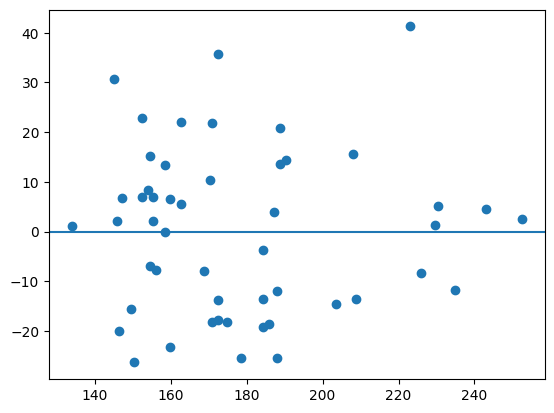

In [42]:
plt.scatter(cvd_res['prediction'], cvd_res['residual'])
plt.axhline(0)

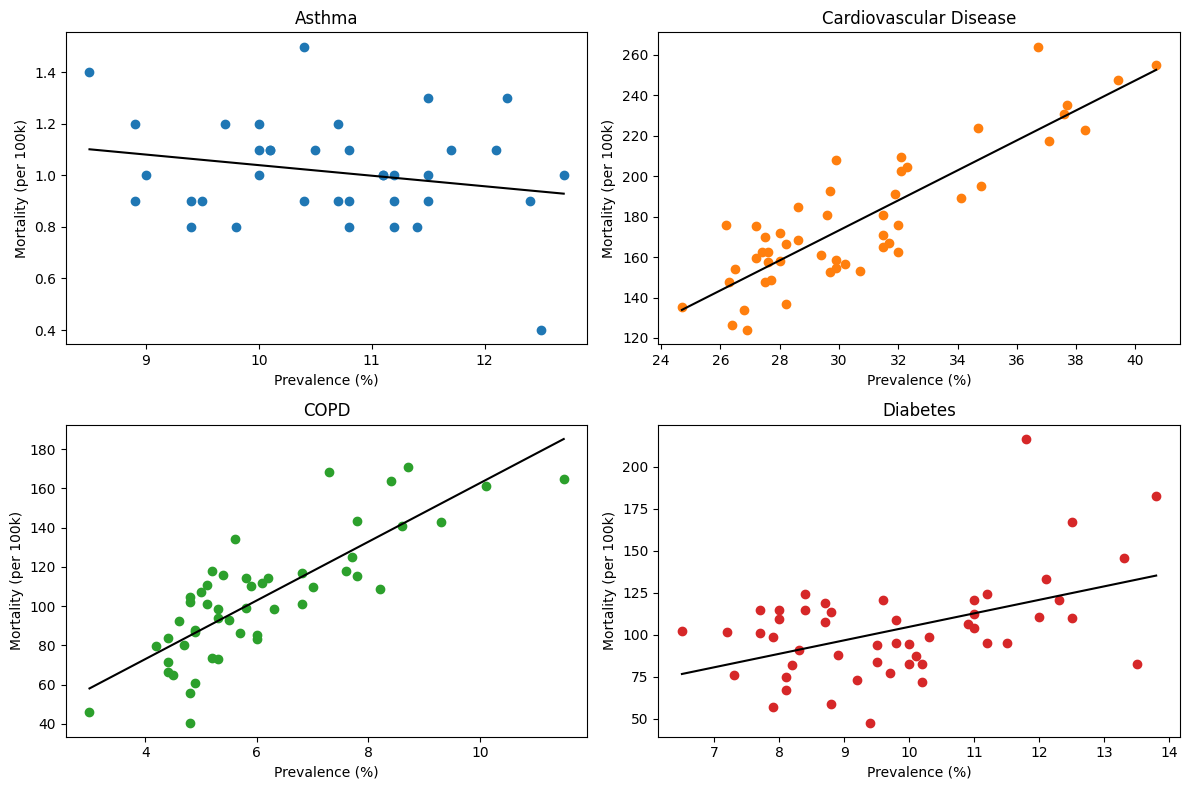

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

diseases_colors = [
    ('Asthma', 'tab:blue'),
    ('Cardiovascular Disease', 'tab:orange'),
    ('Chronic Obstructive Pulmonary Disease', 'tab:green'),
    ('Diabetes', 'tab:red')
]

for ax, (disease, color) in zip(axes.flat, diseases_colors):
    d = results_df[results_df['Topic'] == disease].sort_values('prevalence %')
    ax.scatter(d['prevalence %'], d['mortality per 100k'], color=color)
    ax.plot(d['prevalence %'], d['prediction'], color='black', linewidth=1.5)
    ax.set_xlabel('Prevalence (%)')
    ax.set_ylabel('Mortality (per 100k)')
    ax.set_title(disease if disease != 'Chronic Obstructive Pulmonary Disease' else 'COPD')

plt.tight_layout()
plt.show()